In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (make sure the file is in the same folder as your notebook)
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Display basic info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Data types
print(df.dtypes)

# Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [3]:
# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract year and month for later analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [4]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {margin:.2f}%")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Profit Margin: 12.47%


## Business Insight 1: Overall Profitability
- The company has generated **$2.3M in sales** and **$286k in profit**, with an overall margin of **12.5%**.
- This is a healthy margin for a retail business, but there is room for improvement by addressing loss-making products and regions.

In [5]:
profit_by_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(profit_by_subcat)

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


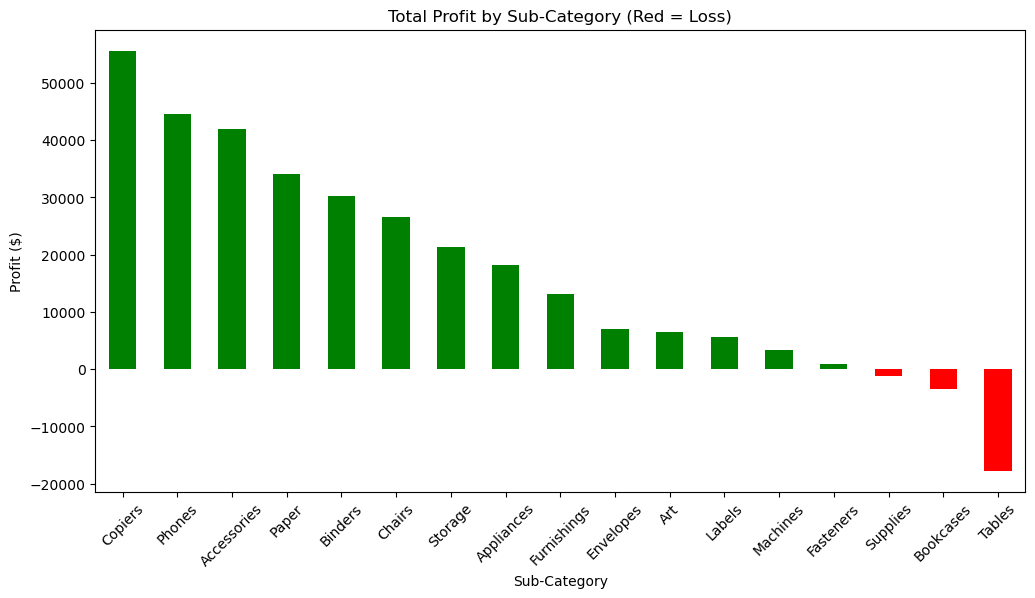

In [6]:
plt.figure(figsize=(12,6))
colors = ['green' if x > 0 else 'red' for x in profit_by_subcat.values]
profit_by_subcat.plot(kind='bar', color=colors)
plt.title('Total Profit by Sub-Category (Red = Loss)')
plt.ylabel('Profit ($)')
plt.xticks(rotation=45)
plt.show()

## Business Insight 2: Profit by Product Sub‑Category
- **Copiers, Phones, and Accessories** are the most profitable sub‑categories.
- **Tables and Bookcases** are **unprofitable** – they lose money overall (negative total profit).
- **Recommendation:**  
  - Increase marketing spend on high‑profit sub‑categories (Copiers, Phones).  
  - Review pricing and discount strategies for Tables and Bookcases. Consider discontinuing the worst‑performing SKUs or bundling them with profitable chairs.

In [7]:
region_summary = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).round(2)
region_summary['Margin %'] = (region_summary['Profit'] / region_summary['Sales'] * 100).round(2)
print(region_summary)

             Sales     Profit  Margin %
Region                                 
Central  501239.89   39706.36      7.92
East     678781.24   91522.78     13.48
South    391721.90   46749.43     11.93
West     725457.82  108418.45     14.94


## Business Insight 3: Regional Performance
- **West region** has the highest profit margin (14.9%), followed by East (13.5%) and South (11.9%).
- **Central region** has the lowest margin (7.9%) despite decent sales volume.
- **Recommendation:**  
  - Investigate shipping costs, discount levels, and sales team performance in the Central region.  
  - Replicate successful strategies from the West region (e.g., product mix, pricing).

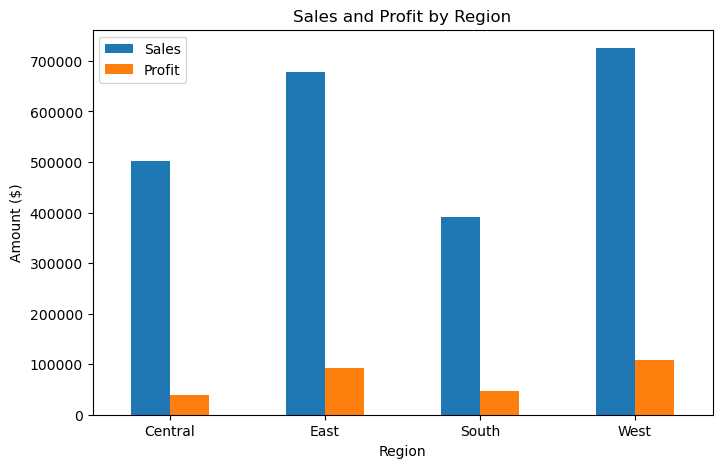

In [8]:
region_summary[['Sales', 'Profit']].plot(kind='bar', figsize=(8,5))
plt.title('Sales and Profit by Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

Sub-Category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Envelopes      0.080315
Accessories    0.078452
Supplies       0.076842
Paper          0.074891
Art            0.074874
Storage        0.074704
Labels         0.068681
Name: Discount, dtype: float64


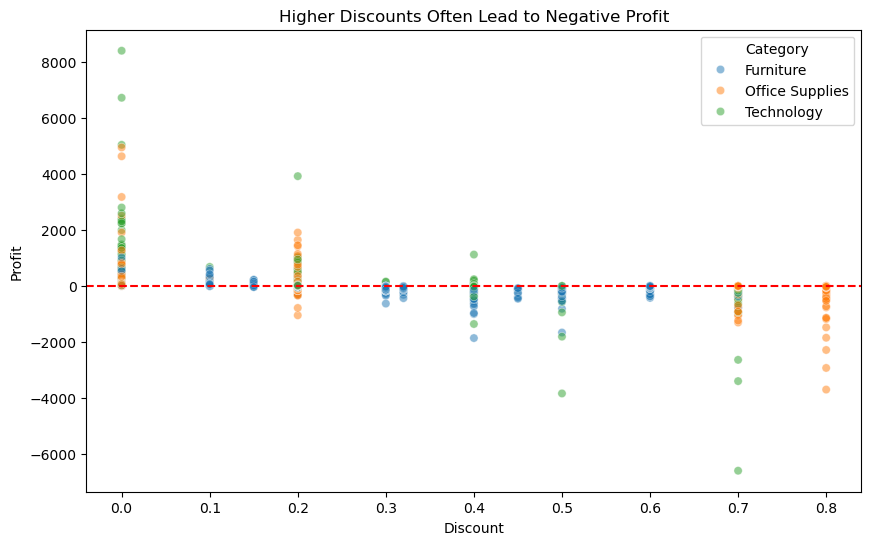

In [9]:
# Average discount per sub-category
discount_by_subcat = df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)
print(discount_by_subcat)

# Scatter plot: Discount vs Profit
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5, hue='Category')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Higher Discounts Often Lead to Negative Profit')
plt.show()

## Business Insight 4: Impact of Discounts on Profit
- The scatter plot clearly shows that **discounts above 20%** frequently lead to **negative profit**.
- Many transactions with high discounts result in losses.
- **Recommendation:**  
  - Implement a company‑wide policy to **cap discounts at 15%** for most products.  
  - Require managerial approval for any discount exceeding 15%.  
  - Run A/B tests to find the optimal discount level for each sub‑category.

In [10]:
segment_summary = df.groupby('Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).round(2)
segment_summary['Margin %'] = (segment_summary['Profit'] / segment_summary['Sales'] * 100).round(2)
print(segment_summary)

                  Sales     Profit  Margin %
Segment                                     
Consumer     1161401.34  134119.21     11.55
Corporate     706146.37   91979.13     13.03
Home Office   429653.15   60298.68     14.03


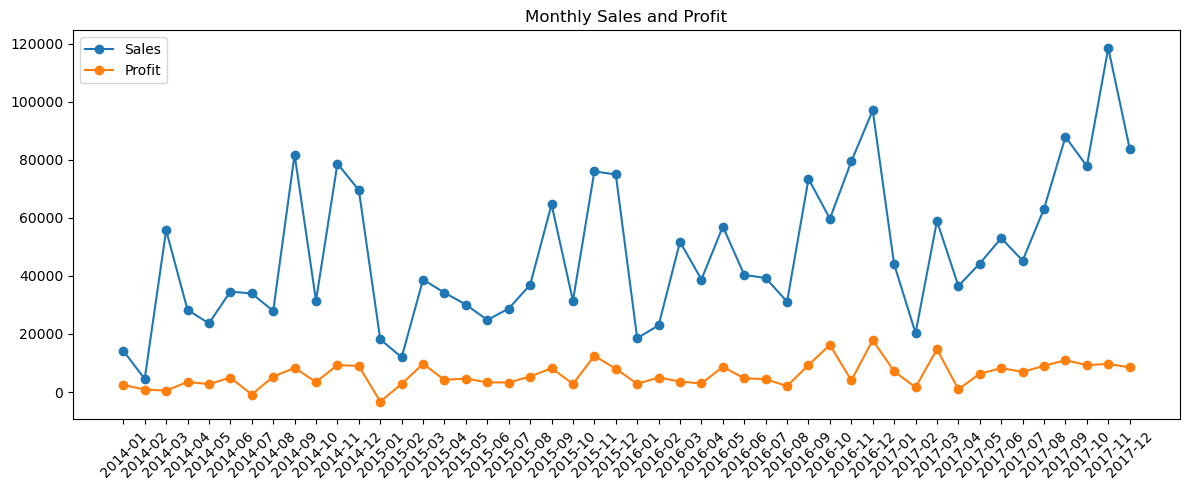

In [11]:
# Group by Year-Month
monthly = df.groupby(df['Order Date'].dt.to_period('M')).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()
monthly['Order Date'] = monthly['Order Date'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly['Order Date'], monthly['Sales'], label='Sales', marker='o')
plt.plot(monthly['Order Date'], monthly['Profit'], label='Profit', marker='o')
plt.xticks(rotation=45)
plt.legend()
plt.title('Monthly Sales and Profit')
plt.tight_layout()
plt.show()

## Business Insight 5: Seasonal Revenue Trends
- Sales spike in **November and December** (holiday season) and drop sharply in **January**.
- **Recommendation:**  
  - Increase inventory and launch marketing campaigns in **October** to capture early holiday shoppers.  
  - Offer post‑holiday clearance events in January to smooth revenue and clear excess stock.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Encode categorical variables
le_category = LabelEncoder()
le_region = LabelEncoder()
le_segment = LabelEncoder()

df['Category_code'] = le_category.fit_transform(df['Category'])
df['Region_code'] = le_region.fit_transform(df['Region'])
df['Segment_code'] = le_segment.fit_transform(df['Segment'])

# Features and target
X = df[['Sales', 'Quantity', 'Discount', 'Category_code', 'Region_code', 'Segment_code']]
y = df['Profit']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(f"R²: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):.2f}")

# Coefficients
coeff_df = pd.DataFrame({
    'Feature': ['Sales', 'Quantity', 'Discount', 'Category', 'Region', 'Segment'],
    'Coefficient': model.coef_
})
print(coeff_df)

R²: -0.720
MAE: $69.35
    Feature  Coefficient
0     Sales     0.258341
1  Quantity    -6.393039
2  Discount  -209.060335
3  Category    22.517602
4    Region    -3.727792
5   Segment     2.209769


This simple linear model performs poorly (negative R²), indicating that profit depends on non‑linear relationships or missing features. A more advanced model (e.g., with interaction terms or tree‑based methods) would be needed for accurate prediction.

## Executive Summary for the Client

**Key Metrics:**
- Total Sales: $2.30M  
- Total Profit: $286k  
- Overall Margin: 12.5%

**Top 3 Actions to Improve Profitability:**

1. **Fix loss‑making Furniture sub‑categories** (Tables & Bookcases) by reducing discounts or discontinuing items.
2. **Optimize discounts** – set a maximum of 15% for most products.
3. **Boost Central region** performance by auditing shipping costs and sales tactics.

**Next Steps:**
- Run a deeper analysis on customer segments to identify retention opportunities (Task 2).
- Use the predictive model (even with low accuracy) as a baseline to explore more advanced features.

*All code, data, and visualizations are included in this notebook.*